In [1]:
# =========================
# 0. IMPORTS
# =========================
import os
import h5py
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
!pip install grad-cam
mpl.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 18,

    "axes.linewidth": 1.2,
    "lines.linewidth": 2.2,

    # SVG için önemli
    "svg.fonttype": "none"
})
# =========================
# 1. DATASET & PID SPLIT
# =========================
def get_pid_mapping(data_dir):
    pid_map = {}
    for f in os.listdir(data_dir):
        if f.endswith(".mat"):
            path = os.path.join(data_dir, f)
            with h5py.File(path, 'r') as hf:
                pid = "".join([chr(c[0]) for c in hf['cjdata']['PID']])
            pid_map.setdefault(pid, []).append(path)
    return pid_map


class BrainTumorDataset(Dataset):
    def __init__(self, files, transform=None):
        self.files = files
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        with h5py.File(self.files[idx], 'r') as f:
            img = np.array(f['cjdata']['image']).astype(np.float32)
            label = int(np.array(f['cjdata']['label'])[0][0]) - 1

        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        img = np.stack([img] * 3, axis=-1)

        if self.transform:
            img = self.transform(img)

        return img, label


# =========================
# 2. MODELS
# =========================
class DenseNet121(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.model = models.densenet121(weights="IMAGENET1K_V1")
        self.model.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(1024, num_classes)
        )

    def forward(self, x):
        return self.model(x)


class EfficientNetB3(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.model = models.efficientnet_b3(weights="IMAGENET1K_V1")
        self.model.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(self.model.classifier[1].in_features, num_classes)
        )

    def forward(self, x):
        return self.model(x)


# =========================
# 3. TRAIN FUNCTION
# =========================

def train_model(model, train_loader, val_loader, device, save_name):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

    best_f1 = 0
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_f1": [],
        "val_acc": []
    }

    for epoch in range(40):
        # -------- TRAIN --------
        model.train()
        running_loss = 0.0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        history["train_loss"].append(train_loss)

        # -------- VALIDATION --------
        model.eval()
        val_loss = 0.0
        preds, gts = [], []

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                preds.extend(outputs.argmax(1).cpu().numpy())
                gts.extend(labels.cpu().numpy())

        val_loss /= len(val_loader)
        f1 = f1_score(gts, preds, average="macro")
        acc = accuracy_score(gts, preds)

        history["val_loss"].append(val_loss)
        history["val_f1"].append(f1)
        history["val_acc"].append(acc)

        print(f"[{save_name}] Epoch {epoch+1} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val F1: {f1:.4f} | "
              f"Val Acc: {acc:.4f}")

        if f1 > best_f1:
            best_f1 = f1
            torch.save(model.state_dict(), f"{save_name}.pth")

    print(f"✅ Best {save_name} Macro-F1: {best_f1:.4f}")
    return history

# =========================
# 4. WEIGHTED SOFT VOTING LOGIC
# =========================
def get_model_probs(model, loader, device):
    """Extracts softmax probabilities from a model."""
    model.eval()
    all_probs = []
    all_labels = []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            probs = torch.softmax(model(imgs), dim=1)
            all_probs.append(probs.cpu())
            all_labels.append(labels)
    return torch.cat(all_probs), torch.cat(all_labels)

def optimize_ensemble_weights(p1, p2, labels):
    """Finds the best weights for Soft Voting by iterating 0.0 to 1.0."""
    best_f1 = 0
    best_w = 0.5
    for i in range(101):
        w1 = i / 100.0
        w2 = 1.0 - w1
        combined = (w1 * p1) + (w2 * p2)
        preds = combined.argmax(1)
        f1 = f1_score(labels, preds, average="macro")
        if f1 > best_f1:
            best_f1 = f1
            best_w = w1
    return best_w, 1.0 - best_w
DATA_DIR = "/kaggle/input/figshare-brain-tumor-dataset/dataset/data"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

pid_map = get_pid_mapping(DATA_DIR)
train_pids, val_pids = train_test_split(list(pid_map.keys()), test_size=0.2, random_state=42)
train_files = [f for p in train_pids for f in pid_map[p]]
val_files = [f for p in val_pids for f in pid_map[p]]

train_tfms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_tfms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

train_loader = DataLoader(BrainTumorDataset(train_files, train_tfms), batch_size=16, shuffle=True)
val_loader = DataLoader(BrainTumorDataset(val_files, val_tfms), batch_size=16, shuffle=False)

# Initialize and Train
dense = DenseNet121().to(DEVICE)
eff = EfficientNetB3().to(DEVICE)

hist_dense = train_model(dense, train_loader, val_loader, DEVICE, "densenet121")
hist_eff = train_model(eff, train_loader, val_loader, DEVICE, "efficientnet_b3")

# Load Best Weights
dense.load_state_dict(torch.load("densenet121.pth"))
eff.load_state_dict(torch.load("efficientnet_b3.pth"))

# =========================
# 6. ENSEMBLE EVALUATION
# =========================
print("\n--- Finding Optimal Ensemble Weights ---")
p_dense, y_true_tensor = get_model_probs(dense, val_loader, DEVICE)
p_eff, _ = get_model_probs(eff, val_loader, DEVICE)

w_dense, w_eff = optimize_ensemble_weights(p_dense, p_eff, y_true_tensor)
print(f"Optimal Weights: DenseNet={w_dense:.2f}, EfficientNet={w_eff:.2f}")

final_probs = (w_dense * p_dense) + (w_eff * p_eff)
y_pred = final_probs.argmax(1).numpy()
y_true = y_true_tensor.numpy()

acc_w = accuracy_score(y_true, y_pred)
f1_w = f1_score(y_true, y_pred, average="macro")

print(f"\n🔥 OPTIMIZED ENSEMBLE | Accuracy: {acc_w:.4f} | Macro-F1: {f1_w:.4f}")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 53.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=1b98a6636fb6cf0ea4b4fbb7b94b767b5f79336165bb042dfdd79301bfc81b1e
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 147MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 139MB/s]


[densenet121] Epoch 1 | Train Loss: 0.5158 | Val Loss: 0.5434 | Val F1: 0.8567 | Val Acc: 0.8624
[densenet121] Epoch 2 | Train Loss: 0.4047 | Val Loss: 0.4575 | Val F1: 0.9183 | Val Acc: 0.9187
[densenet121] Epoch 3 | Train Loss: 0.3787 | Val Loss: 0.5079 | Val F1: 0.8946 | Val Acc: 0.8972
[densenet121] Epoch 4 | Train Loss: 0.3719 | Val Loss: 0.4700 | Val F1: 0.9214 | Val Acc: 0.9204
[densenet121] Epoch 5 | Train Loss: 0.3478 | Val Loss: 0.4829 | Val F1: 0.9075 | Val Acc: 0.9088
[densenet121] Epoch 6 | Train Loss: 0.3499 | Val Loss: 0.4919 | Val F1: 0.9124 | Val Acc: 0.9138
[densenet121] Epoch 7 | Train Loss: 0.3450 | Val Loss: 0.4548 | Val F1: 0.9258 | Val Acc: 0.9254
[densenet121] Epoch 8 | Train Loss: 0.3252 | Val Loss: 0.5480 | Val F1: 0.8938 | Val Acc: 0.8972
[densenet121] Epoch 9 | Train Loss: 0.3299 | Val Loss: 0.5443 | Val F1: 0.8921 | Val Acc: 0.8955
[densenet121] Epoch 10 | Train Loss: 0.3432 | Val Loss: 0.4921 | Val F1: 0.8996 | Val Acc: 0.8988
[densenet121] Epoch 11 | Trai

In [2]:
# =========================
# REQUIRED IMPORTS FOR EXPORT
# =========================
import zipfile
import torch
from IPython.display import FileLink, display

# =========================
# 7. EXPORT & DOWNLOAD LINK
# =========================

# Ensure the variables exist (based on our previous ensemble logic)
ensemble_data = {
    'w_dense': w_dense,
    'w_eff': w_eff,
    'model_names': ['densenet121.pth', 'efficientnet_b3.pth'],
    'best_f1': f1_w
}

# 1. Save the meta-parameters (the weights we calculated)
torch.save(ensemble_data, 'ensemble_metadata.pth')

# 2. Package everything into a single ZIP file
zip_name = "brain_tumor_ensemble_model.zip"
with zipfile.ZipFile(zip_name, 'w') as model_zip:
    # Adding the trained weights
    model_zip.write('densenet121.pth')
    model_zip.write('efficientnet_b3.pth')
    # Adding the ensemble configuration
    model_zip.write('ensemble_metadata.pth')

print(f"\n✅ All components saved to {zip_name}")
print("👇 Click the link below to download your final model ensemble:")

# 3. Generate the clickable download link
display(FileLink(zip_name))


✅ All components saved to brain_tumor_ensemble_model.zip
👇 Click the link below to download your final model ensemble:


/kaggle/working/brain_tumor_ensemble_model.zip

Accuracy: 0.9519
Macro Precision: 0.9545, Macro Recall: 0.9540, Macro F1: 0.9538
Classification Report:
               precision    recall  f1-score   support

     Class 0       0.95      0.90      0.93       207
     Class 1       0.99      1.00      0.99       179
     Class 2       0.92      0.96      0.94       217

    accuracy                           0.95       603
   macro avg       0.95      0.95      0.95       603
weighted avg       0.95      0.95      0.95       603



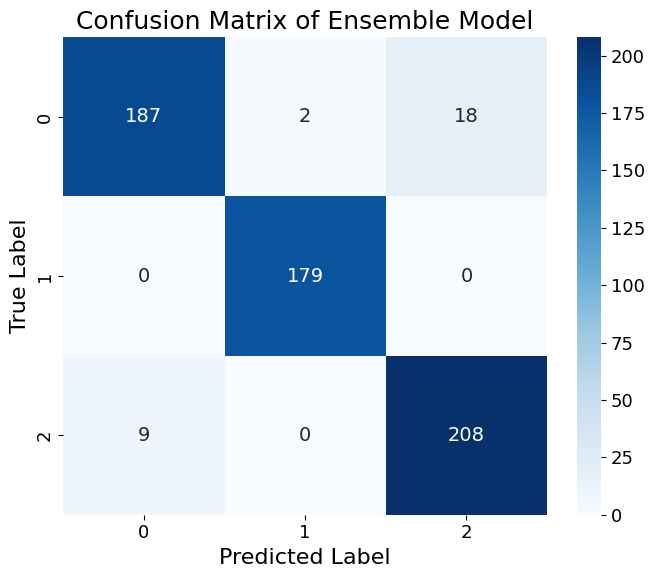

In [3]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F

# =========================
# 7. METRICS & VISUALIZATION
# =========================

# 1. Get predictions & true labels
dense.eval()
eff.eval()
y_true, y_pred, y_probs = [], [], []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(DEVICE)
        labels = labels.numpy()
        out_dense = F.softmax(dense(imgs), dim=1)
        out_eff   = F.softmax(eff(imgs), dim=1)
        
        combined = w_dense * out_dense + w_eff * out_eff
        preds = combined.argmax(1).cpu().numpy()
        
        y_true.extend(labels)
        y_pred.extend(preds)
        y_probs.append(combined.cpu())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probs = torch.cat(y_probs).numpy()

# 2. Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"Accuracy: {acc:.4f}")

# 3. Precision, Recall, F1
precision = precision_score(y_true, y_pred, average="macro")
recall = recall_score(y_true, y_pred, average="macro")
f1 = f1_score(y_true, y_pred, average="macro")
print(f"Macro Precision: {precision:.4f}, Macro Recall: {recall:.4f}, Macro F1: {f1:.4f}")

# Detailed table per class
from sklearn.metrics import classification_report
report = classification_report(y_true, y_pred, target_names=['Class 0','Class 1','Class 2'])
print("Classification Report:\n", report)

# 4. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    annot_kws={"size":14}
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix of Ensemble Model")

plt.tight_layout()

plt.savefig(
    "brain_tumor_confusion_matrix.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()

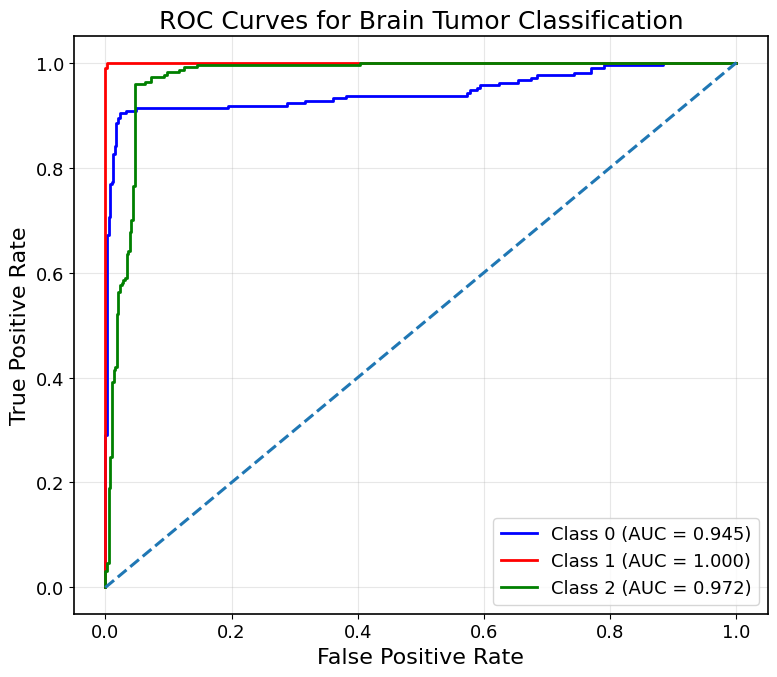

In [4]:

# 5. ROC-AUC (one-vs-rest, multi-class)
from sklearn.preprocessing import label_binarize
n_classes = 3  # 3 for Brain Tumor dataset
y_true_bin = label_binarize(y_true, classes=range(n_classes))

fpr, tpr, roc_auc = dict(), dict(), dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,7))

colors = ['blue', 'red', 'green']

for i, color in zip(range(n_classes), colors):
    plt.plot(
        fpr[i],
        tpr[i],
        color=color,
        lw=2,
        label=f'Class {i} (AUC = {roc_auc[i]:.3f})'
    )

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Brain Tumor Classification")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "brain_tumor_roc_curves.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()

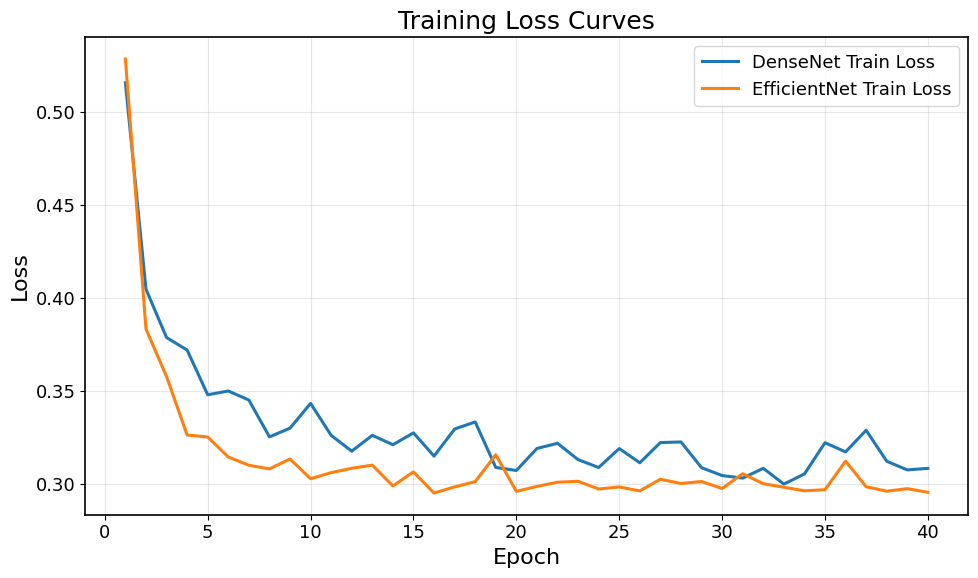

In [5]:
# 6. Training Curves: Train/Val Loss + Accuracy
epochs = range(1, len(hist_dense["train_loss"])+1)

plt.figure(figsize=(10,6))

plt.plot(epochs, hist_dense["train_loss"], label="DenseNet Train Loss")
plt.plot(epochs, hist_eff["train_loss"], label="EfficientNet Train Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curves")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "brain_tumor_training_loss.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()

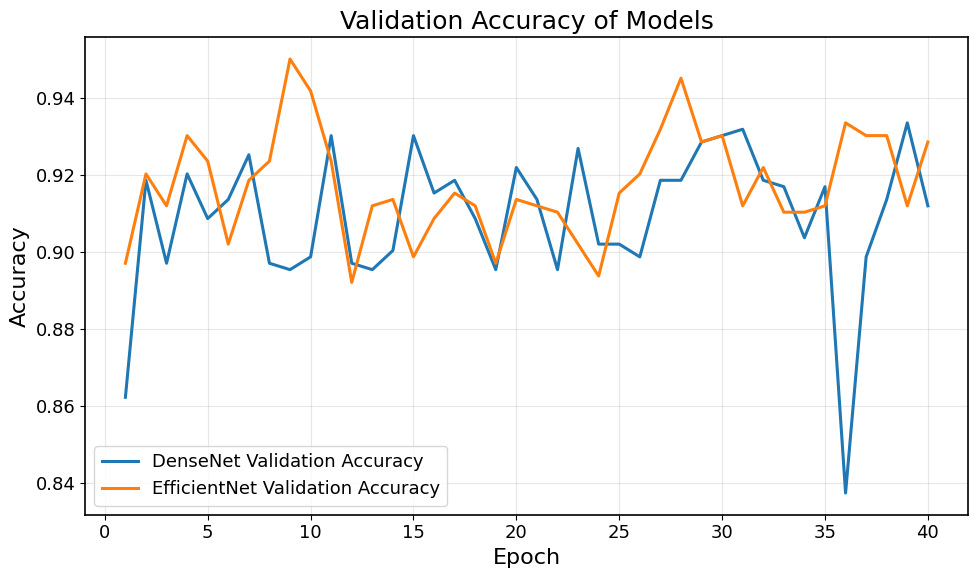

In [6]:
epochs = range(1, len(hist_dense["train_loss"]) + 1)

plt.figure(figsize=(10,6))

# Validation accuracy
plt.plot(
    epochs,
    hist_dense["val_acc"],
    label="DenseNet Validation Accuracy"
)

plt.plot(
    epochs,
    hist_eff["val_acc"],
    label="EfficientNet Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy of Models")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "brain_tumor_accuracy_curve.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()

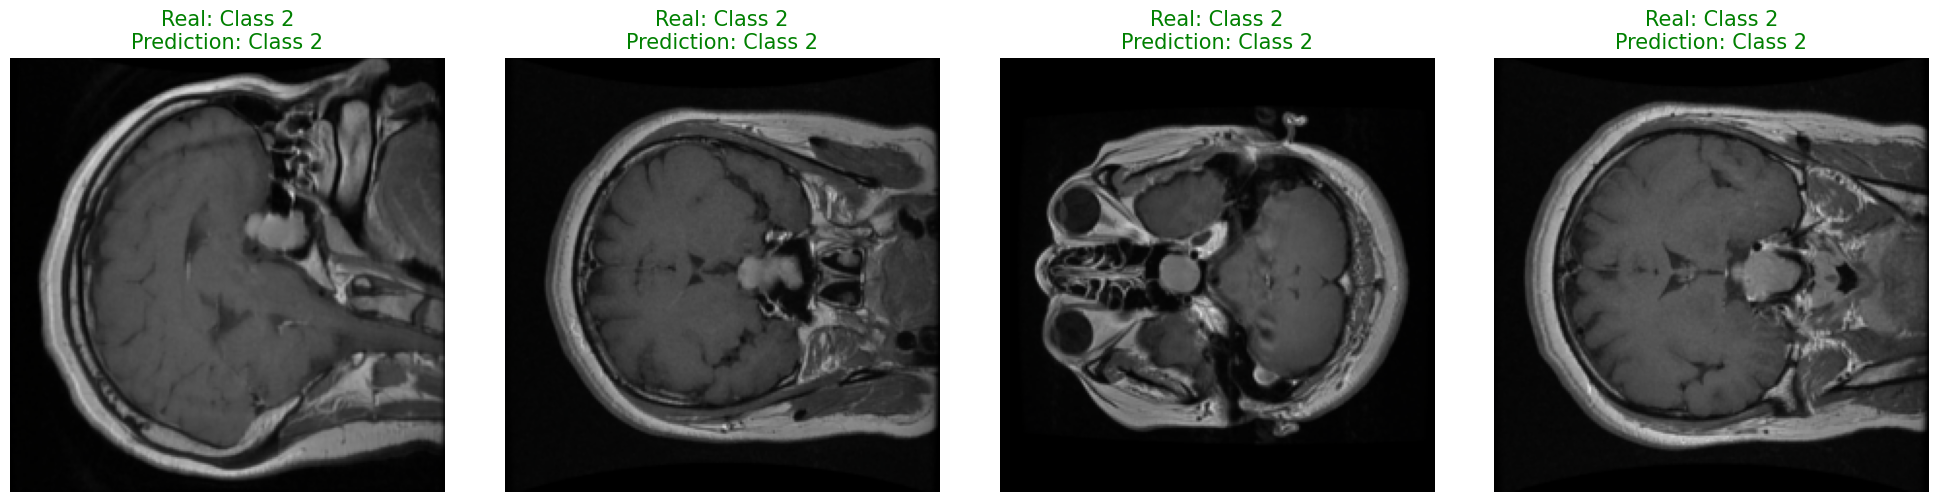

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Görselleri normalizasyondan geri çevirmek için yardımcı fonksiyon
def unnormalize_img(tensor):
    img = tensor.cpu().squeeze().permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    return np.clip(img, 0, 1)

correct_samples = []
incorrect_samples = []

dense.eval()
eff.eval()

# 4 doğru ve 4 yanlış örneği toplama
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(DEVICE)
        out_dense = F.softmax(dense(imgs), dim=1)
        out_eff = F.softmax(eff(imgs), dim=1)
        
        # Ensemble tahmini
        combined = w_dense * out_dense + w_eff * out_eff
        preds = combined.argmax(1).cpu().numpy()
        labels_np = labels.numpy()
        
        for i in range(len(labels_np)):
            is_correct = (preds[i] == labels_np[i])
            
            sample = {
                'tensor': imgs[i].unsqueeze(0), # Grad-CAM için gerekli form (1, C, H, W)
                'image': unnormalize_img(imgs[i]), # Çizim için gerekli form
                'true_label': labels_np[i],
                'pred_label': preds[i]
            }
            
            if is_correct and len(correct_samples) < 4:
                correct_samples.append(sample)
            elif not is_correct and len(incorrect_samples) < 4:
                incorrect_samples.append(sample)
                
        # İkisinden de 4'er tane bulduysak döngüyü kır
        if len(correct_samples) == 4 and len(incorrect_samples) == 4:
            break

# =========================================
# GÖRSELLEŞTİRME 1: DOĞRU TAHMİNLER
# =========================================
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, sample in enumerate(correct_samples):
    axes[i].imshow(sample['image'])
    axes[i].set_title(f"Real: Class {sample['true_label']}\nPrediction: Class {sample['pred_label']}", color="green", fontsize=15)
    axes[i].axis("off")

plt.tight_layout()
plt.savefig("correct_predictions.svg", format="svg", bbox_inches="tight")
plt.show()

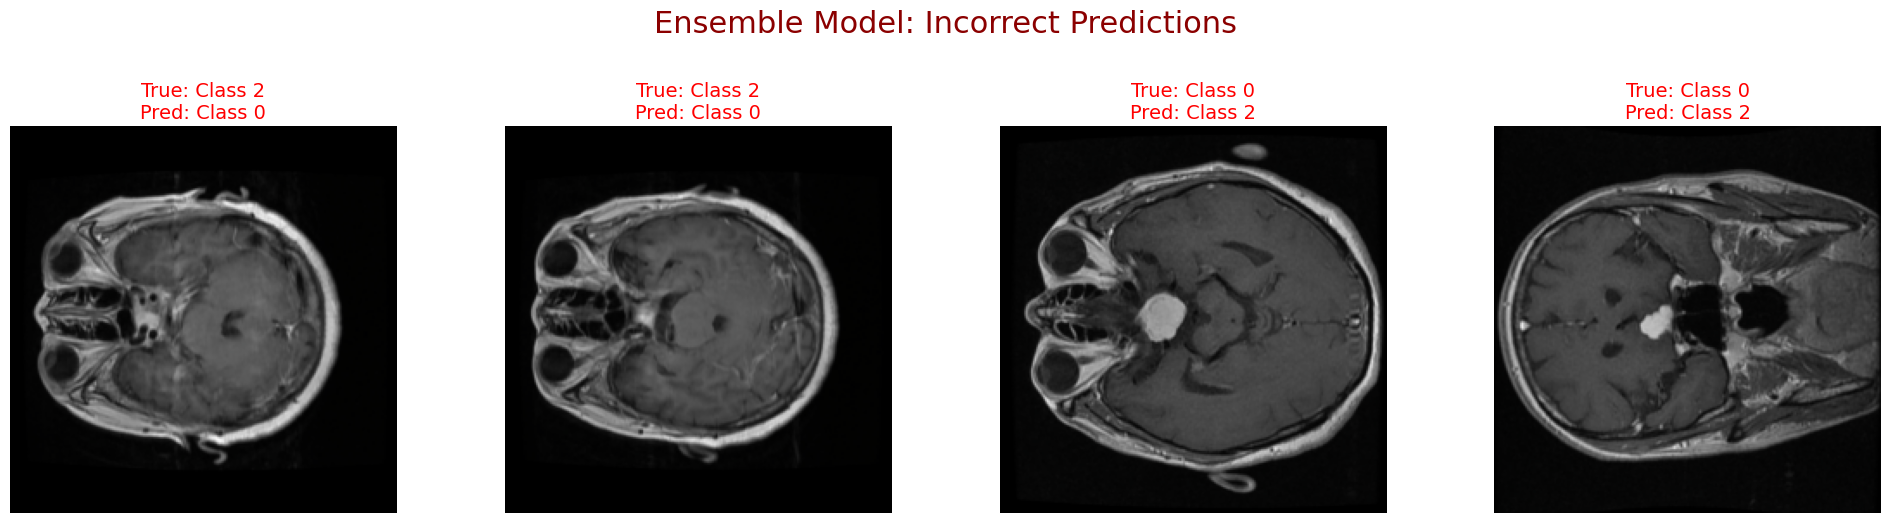

In [8]:

# Yanlış Tahminler
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Ensemble Model: Incorrect Predictions", fontsize=22, y=1.05, color="darkred")
for i, sample in enumerate(incorrect_samples):
    axes[i].imshow(sample['image'])
    axes[i].set_title(f"True: Class {sample['true_label']}\nPred: Class {sample['pred_label']}", color="red", fontsize=14)
    axes[i].axis("off")
plt.tight_layout()
plt.show()

In [9]:
# DenseNet için son conv layer
target_layer_dense = dense.model.features[-1]

# EfficientNet için son conv layer
target_layer_eff = eff.model.features[-1]

In [10]:
def generate_gradcam(model, target_layer, input_tensor, class_idx):
    cam = GradCAM(model=model, target_layers=[target_layer])

    targets = [ClassifierOutputTarget(class_idx)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)

    return grayscale_cam[0]

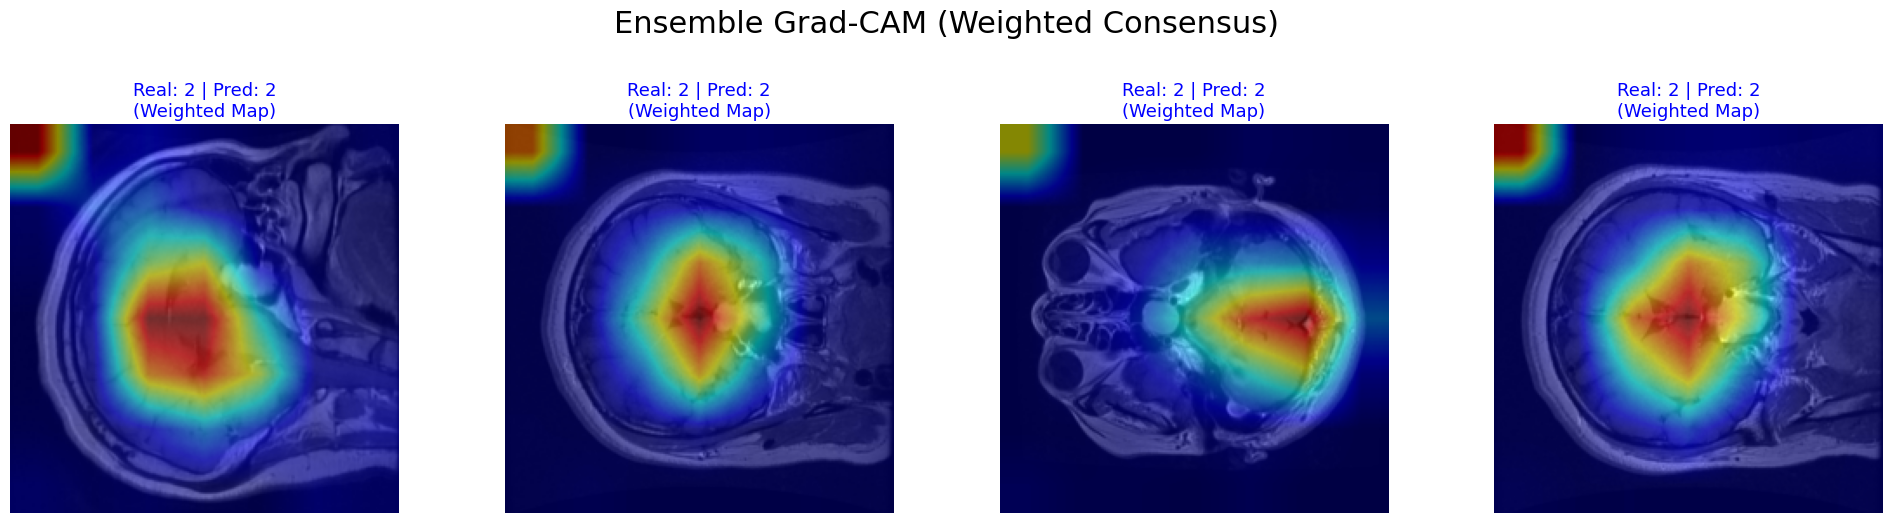

In [11]:
def get_ensemble_gradcam(input_tensor, class_idx):
    """Hem DenseNet hem EfficientNet için CAM üretip ağırlıklı toplar."""
    # DenseNet CAM
    cam_d = generate_gradcam(dense, target_layer_dense, input_tensor, class_idx)
    # EfficientNet CAM
    cam_e = generate_gradcam(eff, target_layer_eff, input_tensor, class_idx)
    
    # Ağırlıklı Birleştirme (Ensemble Weighting)
    ensemble_cam = (w_dense * cam_d) + (w_eff * cam_e)
    
    # Normalizasyon (0-1 aralığına geri çekme)
    ensemble_cam = (ensemble_cam - np.min(ensemble_cam)) / (np.max(ensemble_cam) - np.min(ensemble_cam) + 1e-8)
    return ensemble_cam

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Ensemble Grad-CAM (Weighted Consensus)", fontsize=22, y=1.05)

for i, sample in enumerate(correct_samples):
    input_tensor = sample['tensor'].to(DEVICE)
    image = sample['image']
    pred_class = sample['pred_label']

    # Ensemble CAM Hesapla
    ens_cam = get_ensemble_gradcam(input_tensor, pred_class)

    # Isı haritasını orijinal görsele giydir
    visualization = show_cam_on_image(image, ens_cam, use_rgb=True)

    axes[i].imshow(visualization)
    axes[i].set_title(
        f"Real: {sample['true_label']} | Pred: {pred_class}\n(Weighted Map)",
        color="blue",
        fontsize=13
    )
    axes[i].axis("off")

plt.tight_layout()
plt.savefig("ensemble_gradcam_final.svg", format="svg", bbox_inches="tight")
plt.show()

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Tekil modellerin tahminlerini sınıflara çevir
y_pred_dense = p_dense.argmax(1).numpy()
y_pred_eff = p_eff.argmax(1).numpy()
y_true_all = y_true_tensor.numpy() # Gerçek etiketler

# --- DenseNet121 Metrikleri ---
acc_dense = accuracy_score(y_true_all, y_pred_dense)
prec_dense = precision_score(y_true_all, y_pred_dense, average="macro")
rec_dense = recall_score(y_true_all, y_pred_dense, average="macro")
f1_dense = f1_score(y_true_all, y_pred_dense, average="macro")

# --- EfficientNetB3 Metrikleri ---
acc_eff = accuracy_score(y_true_all, y_pred_eff)
prec_eff = precision_score(y_true_all, y_pred_eff, average="macro")
rec_eff = recall_score(y_true_all, y_pred_eff, average="macro")
f1_eff = f1_score(y_true_all, y_pred_eff, average="macro")

# Çıktıları düzenli bir tablo formatında yazdır
print("\n" + "="*65)
print(" 📊 TEKİL MODELLER VE ENSEMBLE PERFORMANS KARŞILAŞTIRMASI")
print("="*65)
print(f"DenseNet121    -> Accuracy: {acc_dense:.4f} | Precision: {prec_dense:.4f} | Recall: {rec_dense:.4f} | F1: {f1_dense:.4f}")
print(f"EfficientNetB3 -> Accuracy: {acc_eff:.4f} | Precision: {prec_eff:.4f} | Recall: {rec_eff:.4f} | F1: {f1_eff:.4f}")
print("-" * 65)
# Ensemble metrikleri (Sizin 7. bölümünüzde hesaplanan değişkenleri kullanır)
print(f"🔥 ENSEMBLE    -> Accuracy: {acc:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")
print("="*65)


 📊 TEKİL MODELLER VE ENSEMBLE PERFORMANS KARŞILAŞTIRMASI
DenseNet121    -> Accuracy: 0.9337 | Precision: 0.9372 | Recall: 0.9364 | F1: 0.9364
EfficientNetB3 -> Accuracy: 0.9502 | Precision: 0.9526 | Recall: 0.9524 | F1: 0.9520
-----------------------------------------------------------------
🔥 ENSEMBLE    -> Accuracy: 0.9519 | Precision: 0.9545 | Recall: 0.9540 | F1: 0.9538
